## Import Libraries

In [2]:
import os
import random
import warnings
import logging

import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

from peft import LoraConfig, get_peft_model, TaskType

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers.utils.notebook import NotebookProgressCallback

import warnings
warnings.filterwarnings("ignore")

from transformers import logging
logging.set_verbosity_error()

### Device

In [3]:
SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Device:", device)

Device: mps


## Read Data

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
val = pd.read_csv(os.path.join(DATA_PATH, "val.csv"))
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

train.head()

Train: (11528, 2)
Validation: (1442, 2)
Test: (1442, 2)


,comment,labels
0,"Я честно хз, но у меня есть подозрение, что тр...",0
1,"Ну зашибись. Мне гланды удалили, остаётся полз...",0
2,Это когда спрос равен предложению. Если повыша...,0
3,"Ужас, только вчера думала о том, а что, если в...",0
4,"Кроме того, в комплектацию входят прибор ночно...",0


## Prepare Hugging Face Datasets

In [5]:
train_ds = Dataset.from_pandas(
    train[["comment", "labels"]],
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val[["comment", "labels"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test[["comment", "labels"]],
    preserve_index=False
)

train_ds

Dataset({
    features: ['comment', 'labels'],
    num_rows: 11528
})

## Tokenization

In [25]:
MODEL_NAME = "DeepPavlov/rubert-base-cased"
MAX_LENGTH = 256
NUM_LABELS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["comment"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/11528 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

## Dataset Formatting

In [26]:
columns = ["input_ids", "attention_mask", "labels"]

train_ds.set_format("torch", columns=columns)
val_ds.set_format("torch", columns=columns)
test_ds.set_format("torch", columns=columns)

## Load base model

In [27]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## LoRA Configuration

In [28]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    target_modules=["query", "key", "value", "dense"],
    bias="none",
    modules_to_save=["classifier"]
)

model = get_peft_model(base_model, lora_config)

model.print_trainable_parameters()

trainable params: 5,359,106 || all params: 183,214,084 || trainable%: 2.9251


## Define Evaluation Metrics

In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)
    }

## Training Configuration

In [30]:
training_args = TrainingArguments(
    output_dir="./rubert_base_lora",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    num_train_epochs=4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,
    disable_tqdm=False,

    report_to="none",
    dataloader_pin_memory=False,

    seed=SEED
)

## Trainer Initialization

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

## Model Training

In [32]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,2.208826,0.280416,0.892510,0.871041,0.797101,0.832432,0.876655
2,2.334805,0.273866,0.900139,0.813309,0.910973,0.859375,0.890978
3,1.928823,0.269804,0.895284,0.868889,0.809524,0.838156,0.880380
4,1.858396,0.267603,0.901526,0.858947,0.844720,0.851775,0.889023


In [33]:
trainer.remove_callback(NotebookProgressCallback)

## Threshold

In [35]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from scipy.special import softmax

val_outputs = trainer.predict(val_ds)

val_probs = softmax(val_outputs.predictions, axis=1)[:, 1]
val_labels = val_outputs.label_ids

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    val_preds = (val_probs >= threshold).astype(int)

    f1 = f1_score(val_labels, val_preds)
    precision = precision_score(val_labels, val_preds)
    recall = recall_score(val_labels, val_preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_precision = precision
        best_recall = recall

print("Best threshold:", best_threshold)
print("Best validation toxic F1:", best_f1)
print("Precision:", best_precision)
print("Recall:", best_recall)

Best threshold: 0.5599999999999998
Best validation toxic F1: 0.8625498007968128
Precision: 0.8310940499040307
Recall: 0.8964803312629399


## Vaidation Evaluation

In [34]:
val_metrics = trainer.evaluate(val_ds)

for metric, value in val_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 0.27386602759361267
eval_accuracy: 0.9001386962552012
eval_precision: 0.8133086876155268
eval_recall: 0.9109730848861284
eval_f1: 0.859375
eval_macro_f1: 0.8909778225806452
eval_runtime: 19.4073
eval_samples_per_second: 74.302
eval_steps_per_second: 18.601
epoch: 4.0


## Test Evaluation

In [37]:
test_metrics = trainer.evaluate(test_ds)

for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 0.25038576126098633
eval_accuracy: 0.9070735090152566
eval_precision: 0.8261682242990654
eval_recall: 0.9151138716356108
eval_f1: 0.8683693516699411
eval_macro_f1: 0.8982789952347562
eval_runtime: 19.7128
eval_samples_per_second: 73.151
eval_steps_per_second: 18.313
epoch: 4.0


## Classification Report

In [36]:
test_outputs = trainer.predict(test_ds)

test_probs = softmax(test_outputs.predictions, axis=1)[:, 1]
test_labels = test_outputs.label_ids

test_preds = (test_probs >= best_threshold).astype(int)

print(classification_report(
    test_labels,
    test_preds,
    target_names=["non-toxic", "toxic"]
))

              precision    recall  f1-score   support

   non-toxic       0.95      0.91      0.93       959
       toxic       0.83      0.90      0.87       483

    accuracy                           0.91      1442
   macro avg       0.89      0.91      0.90      1442
weighted avg       0.91      0.91      0.91      1442



## Confusion Matrix

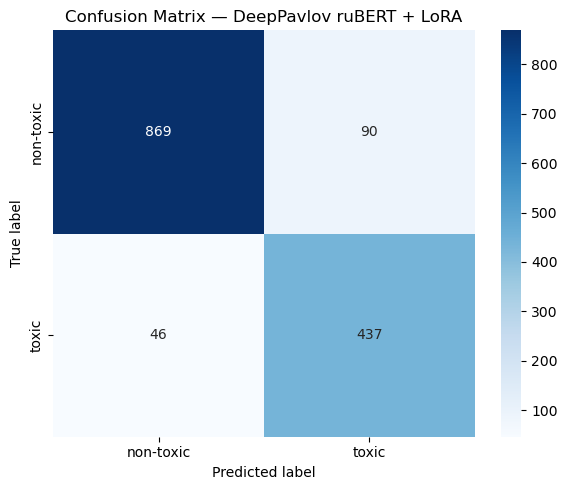

In [44]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["non-toxic", "toxic"],
    yticklabels=["non-toxic", "toxic"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — DeepPavlov ruBERT + LoRA")
plt.tight_layout()
plt.show()

## Save model

In [41]:
SAVE_PATH = "../experiments/deep_pavlov_lora"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved to: {SAVE_PATH}")

Model saved to: ../experiments/deep_pavlov_lora


In [43]:
lora_results = {
    "model": "DeepPavlov ruBERT + LoRA",
    "base_model": MODEL_NAME,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "max_length": MAX_LENGTH,
    "test_accuracy": test_metrics["eval_accuracy"],
    "test_precision": test_metrics["eval_precision"],
    "test_recall": test_metrics["eval_recall"],
    "test_f1": test_metrics["eval_f1"],
    "test_macro_f1": test_metrics["eval_macro_f1"]
}

lora_results

{'model': 'DeepPavlov ruBERT + LoRA',
 'base_model': 'DeepPavlov/rubert-base-cased',
 'lora_r': 16,
 'lora_alpha': 32,
 'lora_dropout': 0.05,
 'max_length': 256,
 'test_accuracy': 0.9070735090152566,
 'test_precision': 0.8261682242990654,
 'test_recall': 0.9151138716356108,
 'test_f1': 0.8683693516699411,
 'test_macro_f1': 0.8982789952347562}